# Исследование рынка общественного питания Москвы

### Цель и задачи 

**Цель исследования**

Определить основные характеристики рынка общественного питания Москвы и выявить факторы, которые могут помочь потенциальному инвестору выбрать оптимальный формат заведения, его расположение и ценовую стратегию.

**Задачи исследования**
- Изучить структуру рынка общественного питания Москвы
- Проанализировать распределение заведений по категориям и районам
- Исследовать соотношение сетевых и несетевых заведений
- Проанализировать вместимость заведений
- Изучить рейтинги и их связь с другими параметрами
- Определить наиболее популярные сети
- Исследовать ценовую политику в зависимости от района
- Сформулировать рекомендации для инвесторов

### Описание данных

В исследовании используются данные о заведениях общественного питания Москвы, включающие информацию о характеристиках заведений, их расположении, рейтингах и ценовой политике.

Использованы два источника данных:

**rest_info.csv**

Содержит основные характеристики заведений:

- `name` — название заведения
- `address` — адрес
- `district` — административный район
- `category` — категория (кафе, ресторан и т.д.)
- `hours` — часы работы
- `rating` — рейтинг (до 5.0)
- `chain` — сетевое (1) или нет (0)
- `seats` — количество посадочных мест

**rest_price.csv**

Содержит информацию о ценовой категории:

- `price` — категория цен
- `avg_bill` — текстовое описание среднего чека
- `middle_avg_bill` — числовой средний чек
- `middle_coffee_cup` — цена капучино

Дополнительно:

- поле `id` использовалось как ключ для объединения таблиц.

### Используемые инструменты

**Язык программирования:**

- Python

**Библиотеки анализа данных:**

- Pandas — обработка и анализ данных
- NumPy — вычисления
- Matplotlib — визуализация
- Seaborn — визуализация
- Phik — расчет корреляции между числовыми и категориальными признаками

**Среда разработки:**

- Jupyter Notebook

**Методы анализа:**

- исследовательский анализ данных (EDA);
- анализ пропущенных значений;
- поиск дубликатов;
- анализ распределений;
- корреляционный анализ;
- визуализация данных;
- формирование бизнес-рекомендаций.

### Этапы исследования

1. Загрузка и первичная оценка данных
- изучение структуры данных;
- проверка соответствия описанию;
- анализ качества данных.

2. Предобработка данных
- обработка пропусков;
- проверка типов данных;
- поиск и устранение дубликатов;
- создание дополнительных признаков.

3. Исследовательский анализ рынка
- анализ категорий заведений;
- изучение географии размещения;
- сравнение сетевых и несетевых форматов;
- анализ вместимости;
- исследование рейтингов;
- анализ факторов, связанных с рейтингом;
- изучение ценовой политики.

4. Формирование выводов и рекомендаций
- определение перспективных форматов;
- оценка подходящих локаций;
- рекомендации по ценовой стратегии.

### Результаты исследования

В ходе исследования рынка общественного питания Москвы были получены следующие результаты:

- Проведена предобработка двух датасетов: обработаны пропуски и дубликаты, объединены данные, созданы дополнительные признаки для анализа.
- Исследована структура рынка общественного питания Москвы по категориям заведений, административным округам и районам.
- Проанализировано распределение сетевых и несетевых заведений, а также выявлены категории с наибольшей долей сетевых предприятий.
- Изучено распределение количества посадочных мест и определены типичные размеры заведений различных категорий.
- Выполнен анализ рейтингов заведений, выявлены категории с наиболее высокими и низкими средними оценками пользователей.
- Исследованы особенности ценовой политики, включая распределение среднего чека по категориям заведений и административным округам.
- Выполнен корреляционный анализ факторов, связанных с рейтингом заведений, с использованием коэффициента PhiK.
- Определены наиболее распространённые сети общественного питания и проанализированы особенности их присутствия на рынке.
- На основе результатов исследования сформулированы выводы и практические рекомендации по выбору формата заведения, его размера, ценового сегмента и возможной локации.

## Загрузка и первичный обзор данных

In [1]:
# Загружаем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy
import statsmodels
import phik

print("Все библиотеки установлены")

Все библиотеки установлены


In [2]:
# Загружаем датасеты
df_info = pd.read_csv('../data/rest_info.csv')
df_price = pd.read_csv('../data/rest_price.csv')

In [3]:
# Смотрим первые строки
df_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Смотрим первые строки
df_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [5]:
# Выводим общую информацию о датафрейме df_info
df_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   str    
 1   name      8406 non-null   str    
 2   category  8406 non-null   str    
 3   address   8406 non-null   str    
 4   district  8406 non-null   str    
 5   hours     7870 non-null   str    
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), str(6)
memory usage: 591.2 KB


In [6]:
# Выводим общую информацию о датафрейме df_price
df_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   str    
 1   price              3315 non-null   str    
 2   avg_bill           3816 non-null   str    
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), str(3)
memory usage: 158.6 KB


---

#### Промежуточный вывод

**Объем данных:**
- Датафрейм `df_info` содержит **8 406** строк и 9 столбцов.
- Датафрейм `df_price` содержит **4 058** строк и 5 столбцов.

**Соответствие данных описанию:**
- Данные в целом соответствуют описанию. 
- В `df_info` присутствуют все заявленные столбцы: `name`, `address`, `district`, `category`, `hours`, `rating`, `chain`, `seats`.
- В `df_price` присутствуют столбцы `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`.
- В `df_info` и `df_price` есть столбец `id` (не был указан в описании). Это уникальный идентификатор заведения; ключ для объединения таблиц.

**Типы данных:**
- `df_info`: 
  - Числовые столбцы: `rating` (float64), `chain` (int64), `seats` (float64)
  - Текстовые столбцы: `id`, `name`, `category`, `address`, `district`, `hours` (object)
- `df_price`:
  - Числовые столбцы: `middle_avg_bill` (float64), `middle_coffee_cup` (float64)
  - Текстовые столбцы: `id`, `price`, `avg_bill` (object)

**Пропуски в данных:**
- `df_info`:
  - `hours`: 8 406 - 7 870 = **536 пропусков** 
  - `seats`: 8 406 - 4 795 = **3 611 пропусков** 
- `df_price`:
  - `price`: 4 058 - 3 315 = **743 пропуска** 
  - `avg_bill`: 4 058 - 3 816 = **242 пропуска** 
  - `middle_avg_bill`: 4 058 - 3 149 = **909 пропусков** 
  - `middle_coffee_cup`: 4 058 - 535 = **3 523 пропуска** 
  
**Особенности, требующие внимания при предобработке:**
1. Высокая доля пропусков в `seats`, а также наличие в нем значений `NaN` и нецелых чисел
2. Столбец `id` присутствует в обоих датафреймах
3. В `df_price` очень много пропусков в `middle_coffee_cup`


#### Подготовка единого датафрейма

In [7]:
# Объединяем датафреймы по столбцу 'id', используя 'left join', чтобы сохранить все заведения из df_info
df = df_info.merge(df_price, on='id', how='left')

In [8]:
# Проверяем размер итогового датафрейма
print(f"Размер объединенного датафрейма: {df.shape}")

Размер объединенного датафрейма: (8406, 13)


In [9]:
# Смотрим наименования стобцов итогового датафрейма
print(f"Столбцы: {df.columns.tolist()}")

Столбцы: ['id', 'name', 'category', 'address', 'district', 'hours', 'rating', 'chain', 'seats', 'price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup']


In [10]:
# Смотрим первые строки объединенного датафрейма
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


## Предобработка данных

In [11]:
# Повторно выводим типы данных
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), str(8)
memory usage: 853.9 KB


In [12]:
# Приводим столбец 'chain' к булиевому типу данных
df['chain'] = df['chain'].astype(bool)

In [13]:
# Приводим столбец 'seats' (количество посадочных мест) к целочисленному типу данных
df['seats'] = df['seats'].astype('Int64')

In [14]:
# Проверка результатов измения типов данных
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   bool   
 8   seats              4795 non-null   Int64  
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: Int64(1), bool(1), float64(3), str(8)
memory usage: 804.6 KB


#### Анализируем пропущенные значения в данных и проведим их обработку

In [15]:
# Считаем абсолютные пропущенные значения
missing_abs = df.isna().sum().sort_values(ascending=False)

# Считаем относительные пропущенные значения 
missing_pct = (df.isna().mean() * 100).round(2)[missing_abs.index]

# Объединяем в одну таблицу
missing_table = pd.concat([missing_abs, missing_pct], axis=1)
missing_table.columns = ['missing_count', 'missing_percent']

# Выводим результат
missing_table

,missing_count,missing_percent
middle_coffee_cup,7871,93.64
middle_avg_bill,5257,62.54
price,5091,60.56
avg_bill,4590,54.60
seats,3611,42.96
hours,536,6.38
district,0,0.00
category,0,0.00
name,0,0.00
id,0,0.00


In [16]:
# Заполняем пропуски значением 'неизвестно'
df['price'] = df['price'].fillna('неизвестно')

#### Анализируем данные на явные и неявные дубликаты

In [17]:
# Проверяем датафрейм на наличие явных дубликатов
df.duplicated().sum()

np.int64(0)

In [18]:
# Создаем копии столбцов для проверки (приводим к нижнему регистру и убираем пробелы)
df['name_norm'] = df['name'].str.lower().str.strip()
df['address_norm'] = df['address'].str.lower().str.strip()

In [19]:
# Проверяем датафрейм на наличие неявных дубликатов
df.duplicated(subset=['name_norm', 'address_norm']).sum()

np.int64(4)

In [20]:
# Выводим неявные дубликаты
df[df.duplicated(subset=['name_norm', 'address_norm'], keep=False)].head(8)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,name_norm,address_norm
189,072032ce16dc47bfbc63b672c75bd371,Кафе,кафе,"Москва, парк Ангарские Пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,False,<NA>,неизвестно,NaN,NaN,NaN,кафе,"москва, парк ангарские пруды"
215,897ddbc6746c4388b19dc8a9fcdbb488,Кафе,кафе,"Москва, парк Ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,False,<NA>,неизвестно,NaN,NaN,NaN,кафе,"москва, парк ангарские пруды"
1430,62608690e9cc464fbcd980cfd552e334,More poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,False,188,неизвестно,NaN,NaN,NaN,more poke,"москва, волоколамское шоссе, 11, стр. 2"
1511,a69f018d5c064873a3b491b0121bc1b4,More Poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,True,188,неизвестно,NaN,NaN,NaN,more poke,"москва, волоколамское шоссе, 11, стр. 2"
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,Раковарня Клешни и Хвосты,ресторан,"Москва, проспект Мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,False,150,неизвестно,NaN,NaN,NaN,раковарня клешни и хвосты,"москва, проспект мира, 118"
2420,aba1de7ad7d64ac0a3f8684bda29d905,Раковарня Клешни и хвосты,"бар,паб","Москва, проспект Мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,True,150,неизвестно,NaN,NaN,NaN,раковарня клешни и хвосты,"москва, проспект мира, 118"
3091,3c2a73ea79a04be48858fab3685f2f37,Хлеб да Выпечка,булочная,"Москва, Ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,True,276,неизвестно,NaN,NaN,NaN,хлеб да выпечка,"москва, ярцевская улица, 19"
3109,d3116844e4e048f99614eb30be3214e0,Хлеб да выпечка,кафе,"Москва, Ярцевская улица, 19",Западный административный округ,NaN,4.1,False,276,неизвестно,NaN,NaN,NaN,хлеб да выпечка,"москва, ярцевская улица, 19"


In [21]:
# Удаляем неявные дубликаты
df = df.drop_duplicates(subset=['name_norm', 'address_norm'])

In [22]:
# Проверяем результаты удаления неявных дубоикатов 
df.duplicated(subset=['name_norm', 'address_norm']).sum()

np.int64(0)

In [23]:
# Выводим количество строк датафрейма после удаления дубликатов 
df.shape

(8402, 15)

In [24]:
# Удаляем временные столбцы
df = df.drop(columns=['name_norm', 'address_norm'])

#### Создаем столбец `is_24_7` (заведение работает ежедневно и круглосуточно)

In [25]:
# Создаем функцию
def check_24_7(hours):
    # Если значение пустое
    if pd.isna(hours):
        return False
    # Приводим к нижнему регистру
    hours = hours.lower()
    # Проверяем условия
    if 'ежедневно' in hours and ('круглосуточно' in hours or '24' in hours):
        return True
    else:
        return False

In [26]:
# Применяем функцию к столбцу 'hours'
df['is_24_7'] = df['hours'].apply(check_24_7)

In [27]:
# Проверяем результаты 
df[['hours', 'is_24_7']].head(15)

,hours,is_24_7
0,"ежедневно, 10:00–22:00",False
1,"ежедневно, 10:00–22:00",False
2,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",False
3,"ежедневно, 09:00–22:00",False
4,"ежедневно, 10:00–22:00",False
5,"ежедневно, 10:00–23:00",False
6,пн 15:00–04:00; вт-вс 15:00–05:00,False
7,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",False
8,"ежедневно, 10:00–22:00",False
9,"ежедневно, 12:00–00:00",False


#### Промежуточный вывод

В ходе предобработки данных были выполнены следующие шаги:

**1. Преобразование типов данных:**
- Столбец `chain` приведён к логическому типу (bool), что позволяет корректно интерпретировать признак сетевого заведения
- Столбец `seats` приведён к типу Int64, так как количество посадочных мест является целочисленным значением, при этом сохранена возможность хранения пропусков

**2. Анализ и обработка пропущенных значений:**
- Наибольшая доля пропусков наблюдается в столбцах:
  - `middle_coffee_cup` — 93.64%
  - `middle_avg_bill` — 62.54%
  - `price` — 60.56%
  - `avg_bill` — 54.60%
  - `seats` — 42.96%
- Пропуски в столбце `price` заполнены значением "неизвестно".
- Пропуски в остальных столбцах оставлены без изменений, поскольку их удаление привело бы к значительной потере данных

Предположительно, пропуски связаны с отсутствием информации в источниках или тем, что не все заведения указывают ценовую информацию и характеристики

**3. Проверка дубликатов:**
- Явные дубликаты (полностью совпадающие строки) не обнаружены
- Для поиска неявных дубликатов данные были нормализованы (приведение к нижнему регистру и удаление лишних пробелов)
- Обнаружено 4 неявных дубликата по сочетанию `name` и `address`, которые были удалены
- После удаления дубликатов размер датафрейма сократился с 8406 до 8402 строк (менее 0.1% данных)

**4. Создание нового признака:**
- Добавлен столбец `is_24_7`, отражающий круглосуточный режим работы заведения
- Признак принимает значение True, если заведение работает ежедневно и круглосуточно, и False — в остальных случаях

**Итог:**
Данные успешно подготовлены к исследовательскому анализу. Существенных потерь данных не произошло, а качество данных было улучшено за счёт удаления дубликатов и корректной обработки типов и пропусков.

## Исследовательский анализ данных

---
#### Анализируем категории заведений, которые представлены в данных 

In [28]:
# Считаем количество заведений по категориям 
category_counts = df['category'].value_counts()
# Выводим результат
category_counts

category
кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: count, dtype: int64

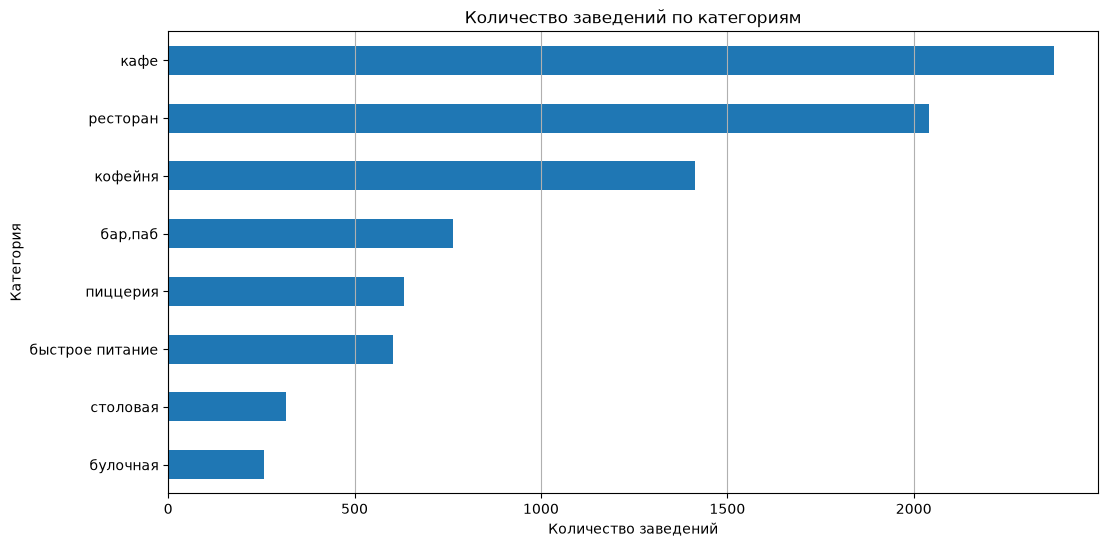

In [29]:
# Строим горизонтальную диаграмму, сортируем значения по убыванию
category_counts.sort_values().plot(
    kind='barh',
    figsize=(12,6)
)
# Наименование графика, оси 'x', оси 'y'
plt.title('Количество заведений по категориям')
plt.xlabel('Количество заведений')
plt.ylabel('Категория')
# Добавляем сетку по оси 'x' для лучшего восприятия 
plt.grid(axis='x')
# Выводим результат
plt.show()

#### Промежуточный вывод по категориям заведений

В данных представлены различные категории заведений общественного питания, включая кафе, рестораны, кофейни, бары, пиццерии и другие форматы.

Наибольшее количество заведений приходится на категории кафе и рестораны, что свидетельствует о высокой популярности данных форматов на рынке общественного питания Москвы. Также значительную долю занимают кофейни.

Менее распространёнными являются специализированные категории, такие как булочные или столовые, что может быть связано с их более узкой целевой аудиторией.

Таким образом, рынок общественного питания Москвы характеризуется преобладанием универсальных форматов заведений, ориентированных на широкий круг посетителей.

---
#### Исследуем административные районы Москвы, которые присутствуют в данных 
(в том числе распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы)

In [30]:
# Считаем количество заведений по районам
district_counts = df['district'].value_counts()
# Выводим результат
district_counts

district
Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: count, dtype: int64

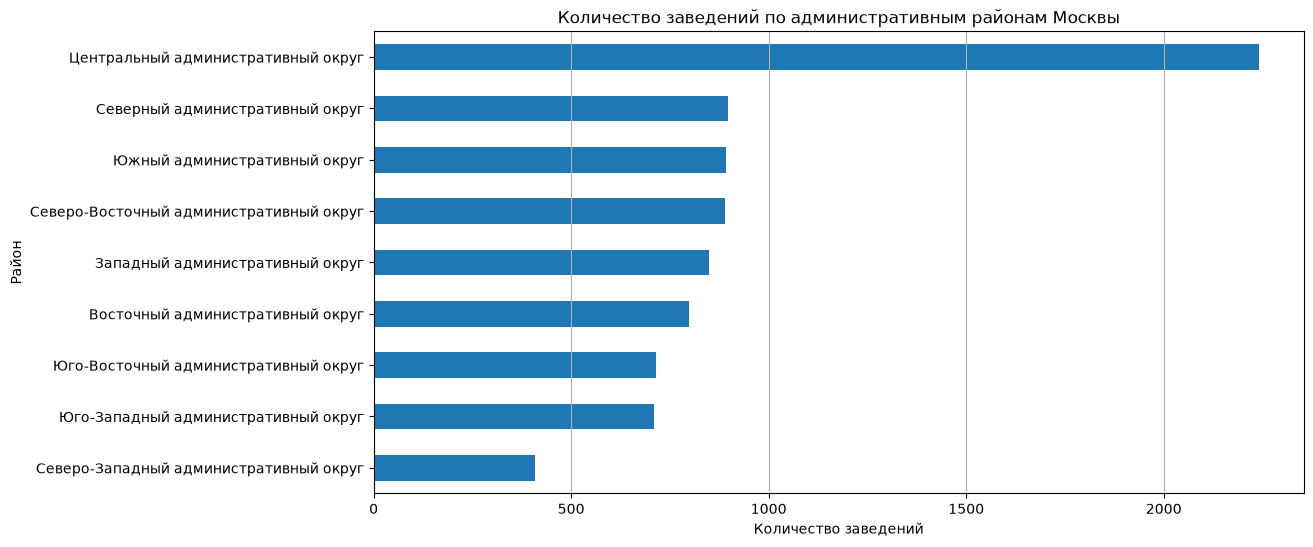

In [31]:
# Строим горизонтальную диаграмму
district_counts.sort_values().plot(
    kind='barh',
    figsize=(12,6)
)

plt.title('Количество заведений по административным районам Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Район')
plt.grid(axis='x')
plt.show()

#### Промежуточный вывод по распределению количества заведений по административным районам Москвы
В данных представлены все основные административные районы Москвы. Наибольшее количество заведений сосредоточено в Центральном административном округе, что объясняется высокой деловой и туристической активностью. В остальных округах количество заведений распределено более равномерно и в целом ниже, чем в центре города.

In [32]:
# Фильтруем только ЦАО
df_cao = df[df['district'] == 'Центральный административный округ']

In [33]:
# Считаем категории в ЦАО
cao_category_counts = df_cao['category'].value_counts()
# Выводим результат
cao_category_counts

category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: count, dtype: int64

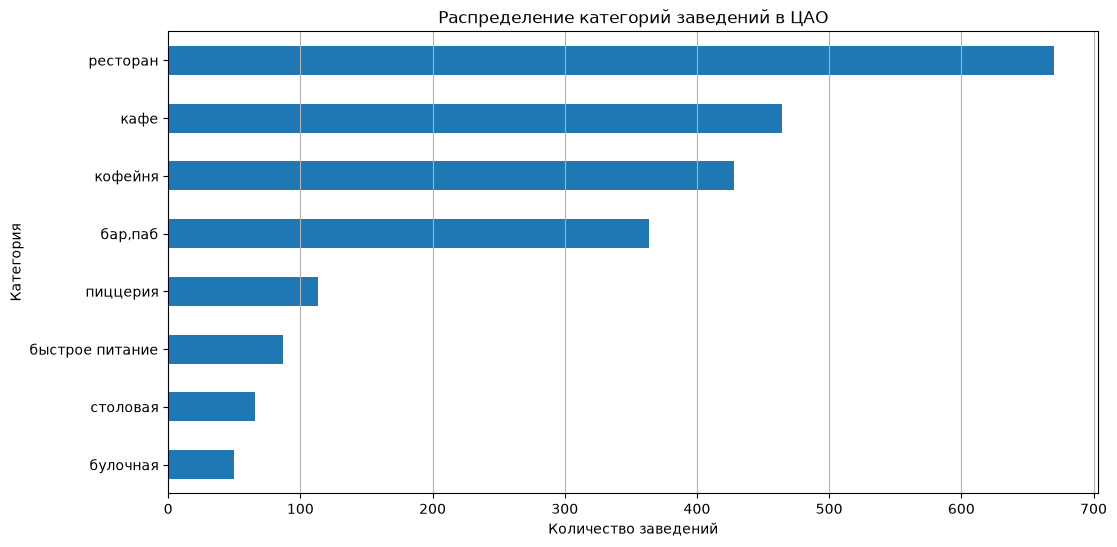

In [34]:
# Строим горизонатльную диаграмму
cao_category_counts.sort_values().plot(
    kind='barh',
    figsize=(12,6)
)
plt.title('Распределение категорий заведений в ЦАО')
plt.xlabel('Количество заведений')
plt.ylabel('Категория')
plt.grid(axis='x')
plt.show()

#### Промежуточный вывод по распределению заведений каждой категории в Центральном административном округе Москвы
В Центральном административном округе Москвы наблюдается высокая концентрация заведений общественного питания, при этом структура рынка отличается разнообразием форматов.

Наибольшее количество заведений представлено в категории ресторанов (670 объектов), что указывает на ориентированность центра города на более высокий уровень сервиса и длительное пребывание посетителей. Значительную долю также занимают кафе (464) и кофейни (428), что отражает высокий спрос на повседневные и быстрые форматы питания.

Существенное присутствие баров и пабов (364) говорит о развитой вечерней и развлекательной инфраструктуре в центре города. Менее распространены пиццерии, заведения быстрого питания, столовые и булочные.

Таким образом, ЦАО характеризуется не только наибольшей плотностью заведений, но и широким разнообразием форматов, с преобладанием ресторанного сегмента и заведений с более высоким уровнем сервиса.

---

#### Анализируем соотношение сетевых и несетевых заведений 

In [35]:
# Считаем количество сетевых и несетвых заведений (False - несетевые, True - сетевые)
chain_counts = df['chain'].value_counts()
# Выводим результаты
chain_counts

chain
False    5199
True     3203
Name: count, dtype: int64

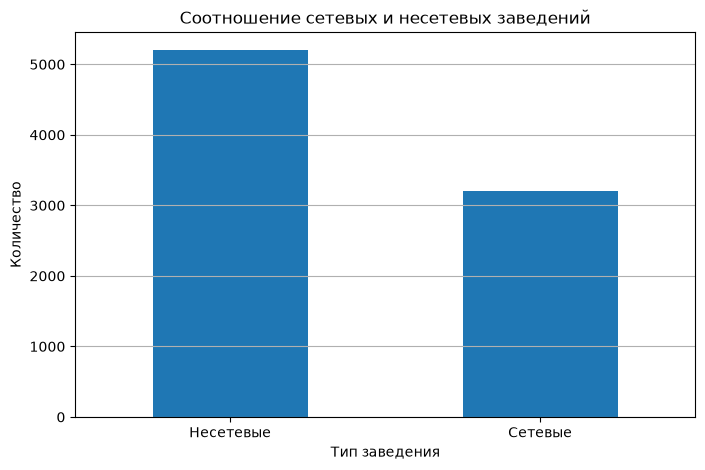

In [36]:
# Строим столбчатую диаграмму 
chain_counts.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Соотношение сетевых и несетевых заведений')
plt.xlabel('Тип заведения')
plt.ylabel('Количество')
# Заменяем '0' и '1' на 'Несетевые' и 'Сетевые'
plt.xticks(ticks=[0,1], labels=['Несетевые', 'Сетевые'], rotation=0)
plt.grid(axis='y')
# Выводим результаты
plt.show()

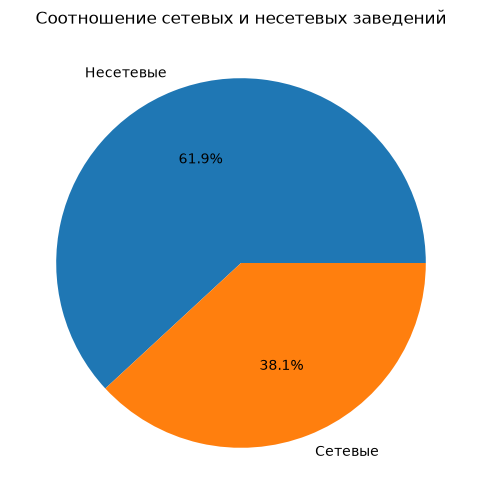

In [37]:
# Круговая диаграмма с долями
plt.figure(figsize=(6,6))
chain_counts.plot(kind='pie', autopct='%1.1f%%', labels=['Несетевые', 'Сетевые'])
plt.title('Соотношение сетевых и несетевых заведений')
plt.ylabel('') 
plt.show()

In [38]:
# Приводим признак сетевого заведения к числовому формату
df['chain'] = df['chain'].astype(int)

# Создаем сводную таблицу в разрезе категорий заведений
category_chain = df.pivot_table(
    index='category',
    columns='chain',
    aggfunc='size',
    fill_value=0
)

# Сортируем категории по количеству сетевых заведений
category_chain = category_chain.sort_values(by=1, ascending=False)

# Переименовываем столбцы для наглядности
category_chain = category_chain.rename(columns={
    0: 'Несетевые',
    1: 'Сетевые'
})

# Рассчитываем общее количество заведений
category_chain['Всего'] = (
    category_chain['Несетевые'] + category_chain['Сетевые']
)

# Рассчитываем доли сетевых и несетевых заведений
category_chain['Доля сетевых (%)'] = (
    category_chain['Сетевые'] / category_chain['Всего'] * 100
).round(1)

category_chain['Доля несетевых (%)'] = (
    category_chain['Несетевые'] / category_chain['Всего'] * 100
).round(1)

# Добавляем строку с итогами
category_chain.loc['ИТОГО'] = [
    category_chain['Несетевые'].sum(),
    category_chain['Сетевые'].sum(),
    category_chain['Всего'].sum(),
    (category_chain['Сетевые'].sum() / category_chain['Всего'].sum() * 100).round(1),
    (category_chain['Несетевые'].sum() / category_chain['Всего'].sum() * 100).round(1)
]

# Выводим результат
category_chain

chain,Несетевые,Сетевые,Всего,Доля сетевых (%),Доля несетевых (%)
category,,,,,
кафе,1597.0,779.0,2376.0,32.8,67.2
ресторан,1313.0,729.0,2042.0,35.7,64.3
кофейня,693.0,720.0,1413.0,51.0,49.0
пиццерия,303.0,330.0,633.0,52.1,47.9
быстрое питание,371.0,232.0,603.0,38.5,61.5
"бар,паб",596.0,168.0,764.0,22.0,78.0
булочная,99.0,157.0,256.0,61.3,38.7
столовая,227.0,88.0,315.0,27.9,72.1
ИТОГО,5199.0,3203.0,8402.0,38.1,61.9


In [39]:
# Создаем таблицу без сторки "ИТОГО" для создания визуализаций
category_chain_plot = category_chain.drop('ИТОГО')

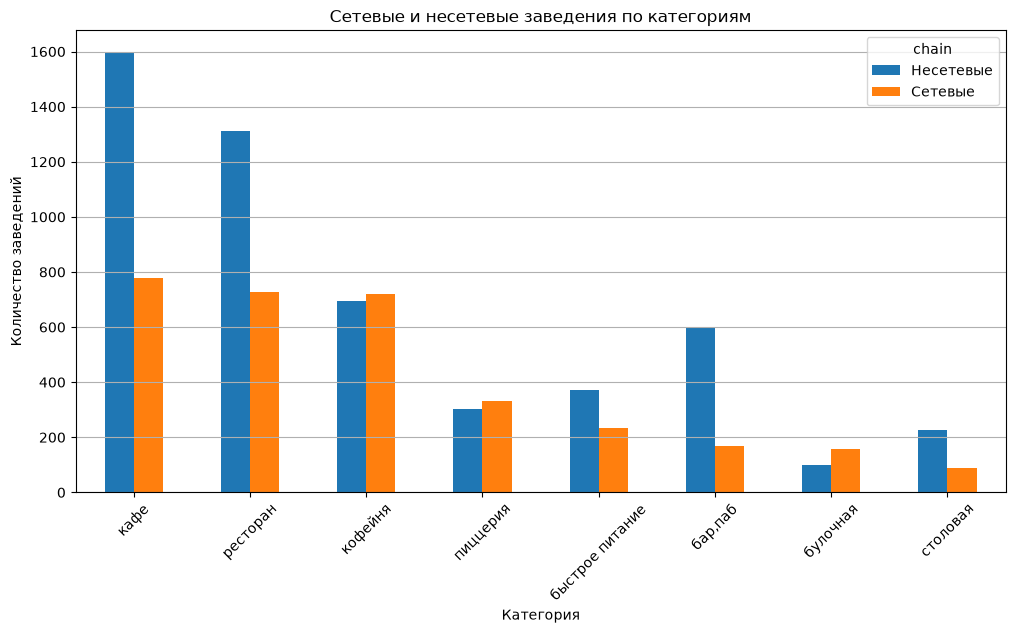

In [40]:
# Строим столбчатую диаграмму для наглядного понимания каких заведений больше
category_chain_plot[['Несетевые', 'Сетевые']].plot(
    kind='bar',
    figsize=(12,6)
)
plt.title('Сетевые и несетевые заведения по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45)
plt.grid(axis='y')
# Выводим результаты
plt.show()

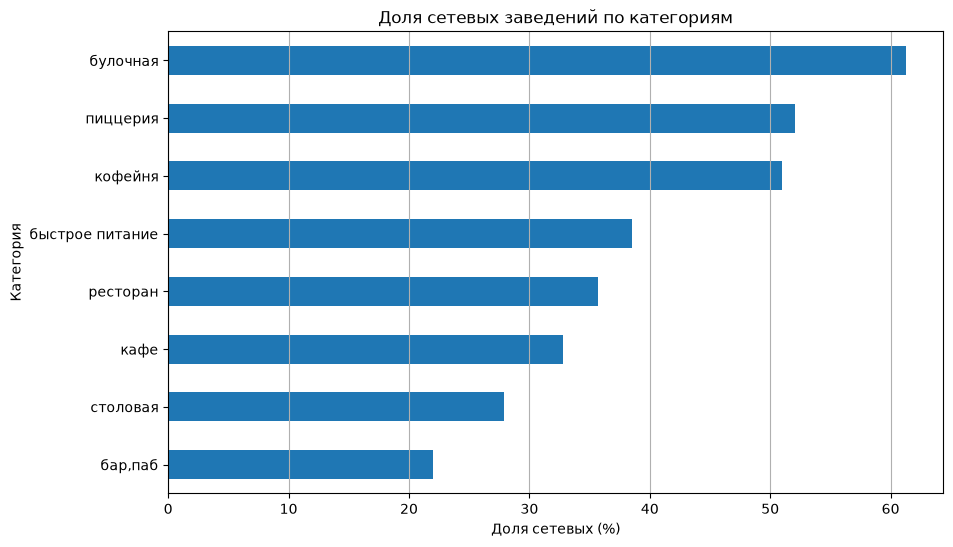

In [41]:
# Строим горизонтальную диаграмму доли сетевых заведений по категориям
category_chain_plot['Доля сетевых (%)'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)
plt.title('Доля сетевых заведений по категориям')
plt.xlabel('Доля сетевых (%)')
plt.ylabel('Категория')
plt.grid(axis='x')
plt.show()

#### Промежуточный вывод по результатам исследования соотношения сетевых и несетевых заведений

В ходе анализа было изучено соотношение сетевых и несетевых заведений.

**Общая структура рынка:**

В выборке преобладают несетевые заведения:
  - несетевые: 5199 (≈62%)
  - сетевые: 3203 (≈38%)

Таким образом, рынок общественного питания Москвы в целом представлен преимущественно независимыми заведениями.

**Анализ по категориям:**

Наибольшая доля сетевых заведений наблюдается в следующих категориях:
- булочные - 61.3%
- пиццерии - 52.1%
- кофейни - 51.0%

Это говорит о том, что данные форматы чаще масштабируются и развиваются в виде сетей.

Наименьшая доля сетевых заведений:
- бары и пабы - 22.0%
- столовые - 27.9%
- кафе - 32.8%

---

#### Анализируем количество посадочных мест в заведениях


In [42]:
# Убираем пропуски в столбце 'seats'
df_seats = df.dropna(subset=['seats'])

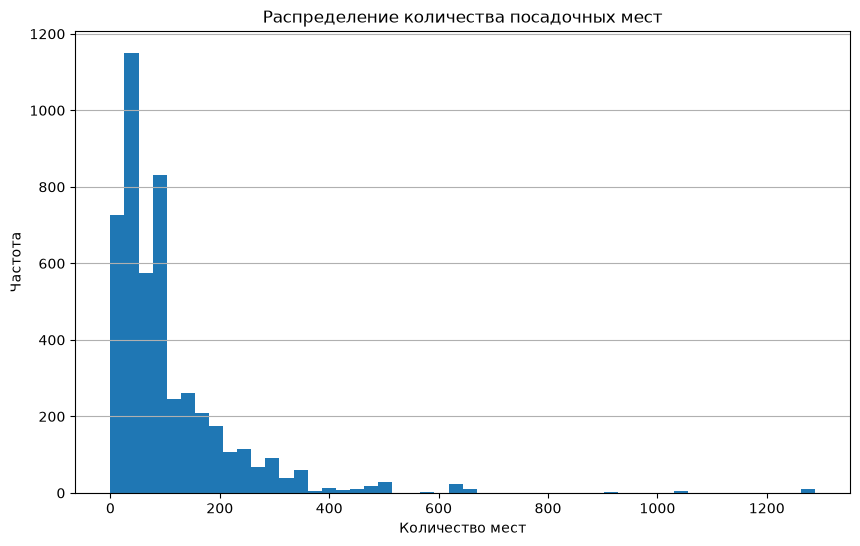

In [43]:
# Строим гистограмму
plt.figure(figsize=(10,6))
df_seats['seats'].plot(
    kind='hist',
    bins=50
)
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество мест')
plt.ylabel('Частота')
plt.grid(axis='y')
plt.show()

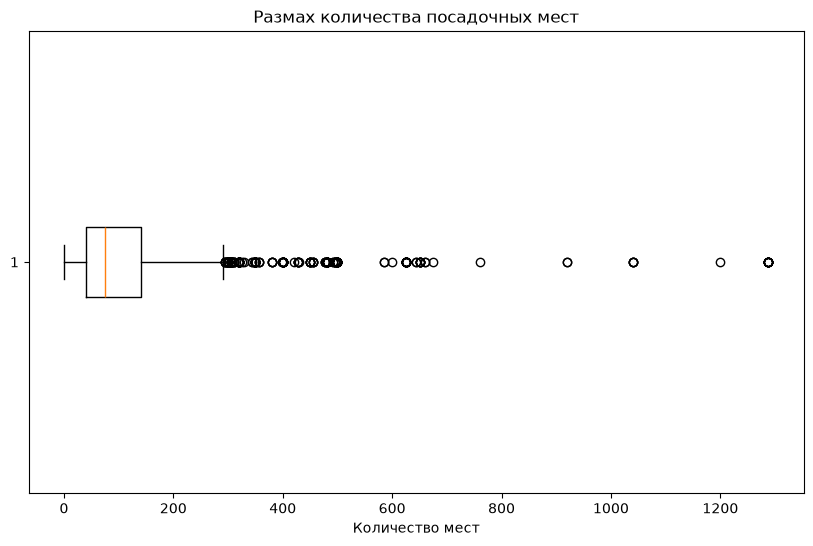

In [44]:
# Строим диаграмму размаха
plt.figure(figsize=(10, 6))
plt.boxplot(df_seats['seats'], orientation='horizontal')

plt.title('Размах количества посадочных мест')
plt.xlabel('Количество мест')

plt.show()

In [45]:
# Смотрим выбросы с помощью числовых показателей
df_seats['seats'].describe()

count        4792.0
mean     108.361436
std       122.84113
min             0.0
25%            40.0
50%            75.0
75%           140.0
max          1288.0
Name: seats, dtype: Float64

In [46]:
# Удаляем выбросы для дальнейшего анализа (оставляем только заведения до 300 мест)
df_seats_filtered = df_seats[df_seats['seats'] <= 300]

<Figure size 1200x600 with 0 Axes>

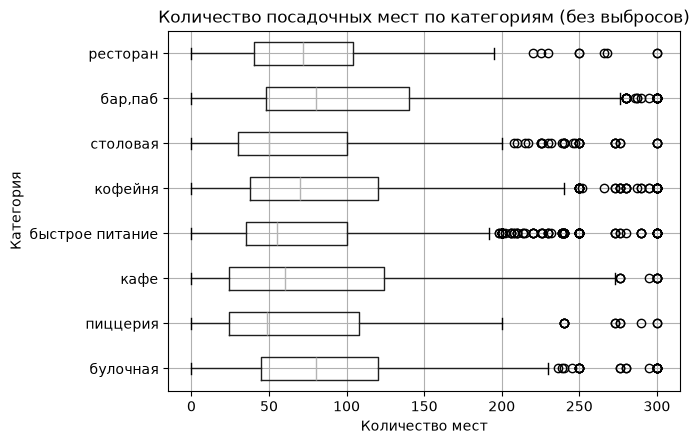

In [47]:
# Добавляем сортировку
category_order = (df_seats_filtered.groupby('category')['seats'].median().sort_values().index)
# Строим диаграмму размах по категориям (без выбросов)
plt.figure(figsize=(12,6))

df_seats_filtered.boxplot(
    column='seats',
    by='category',
    vert=False
)
# Распределяем категории по оси Y в соответствии со списком
plt.yticks(ticks=range(1, len(category_order)+1), labels=category_order)

plt.title('Количество посадочных мест по категориям (без выбросов)')
plt.suptitle('')
plt.xlabel('Количество мест')
plt.ylabel('Категория')

plt.show()

In [48]:
# Смотрим медиану по категориям заведений
seats_by_category = (
    df_seats_filtered
    .groupby('category')['seats']
    .median()
    .sort_values()
)
seats_by_category

category
булочная           48.5
пиццерия           50.0
кафе               55.0
быстрое питание    60.0
кофейня            70.0
столовая           72.0
бар,паб            80.0
ресторан           80.0
Name: seats, dtype: Float64

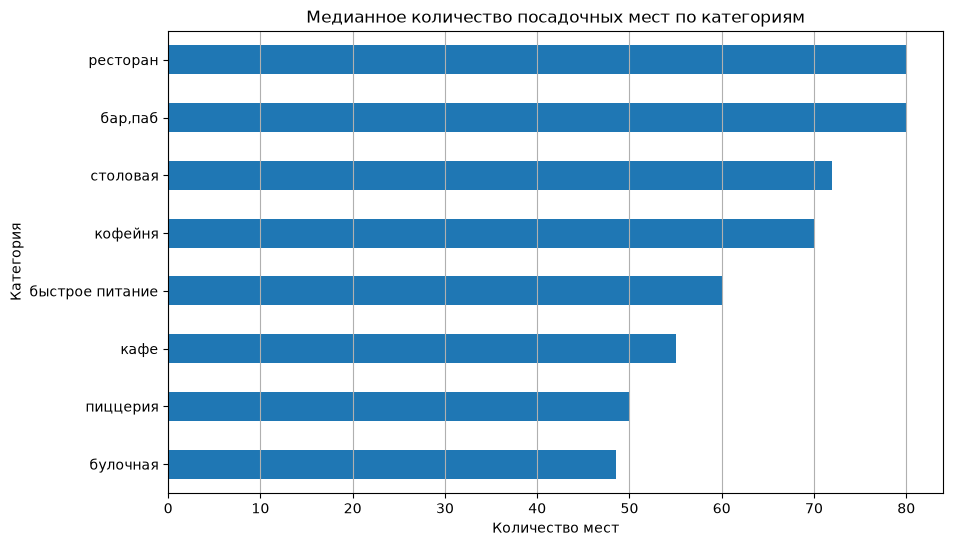

In [49]:
# Строим горизонтальную диаграмму медианного количества мест
seats_by_category.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Медианное количество посадочных мест по категориям')
plt.xlabel('Количество мест')
plt.ylabel('Категория')
plt.grid(axis='x')

plt.show()

#### Промежуточный вывод по результатам исследования количества посадочных мест в заведениях

В ходе анализа количества посадочных мест в заведениях общественного питания были получены следующие результаты:

**Общая картина распределения:**

Распределение количества посадочных мест имеет выраженный правосторонний характер.
Медианное значение составляет 75 мест, в то время как максимальное значение достигает 1288 мест, что свидетельствует о наличии выбросов.

Среднее значение (≈108 мест) значительно превышает медиану, что также указывает на влияние аномально больших значений.

**Выбросы:**

В данных присутствуют значительные выбросы (более 300 посадочных мест).
Они могут быть связаны с:

- крупными ресторанами
- банкетными залами
- столовыми при предприятиях или торговых центрах
- возможными ошибками ввода данных

Для корректного анализа такие значения были временно исключены.

**Анализ по категориям (без выбросов):**

Типичное (медианное) количество посадочных мест по категориям составляет:

- булочные — ~49 мест
- пиццерии — ~50 мест
- кафе — ~55 мест
- быстрое питание — ~60 мест
- кофейни — ~70 мест
- столовые — ~72 места
- бары/пабы — ~80 мест
- рестораны — ~80 мест

Наименьшее количество посадочных мест характерно для:

- булочных
- пиццерий
- кафе

Наибольшее — для:

- ресторанов
- баров и пабов
- столовых

Это связано с форматом заведений:
компактные форматы ориентированы на быстрый поток клиентов, в то время как рестораны и бары предполагают более длительное пребывание гостей.

**Таким образом,** количество посадочных мест существенно зависит от категории заведения.

---

#### Анализируем рейтинг заведений

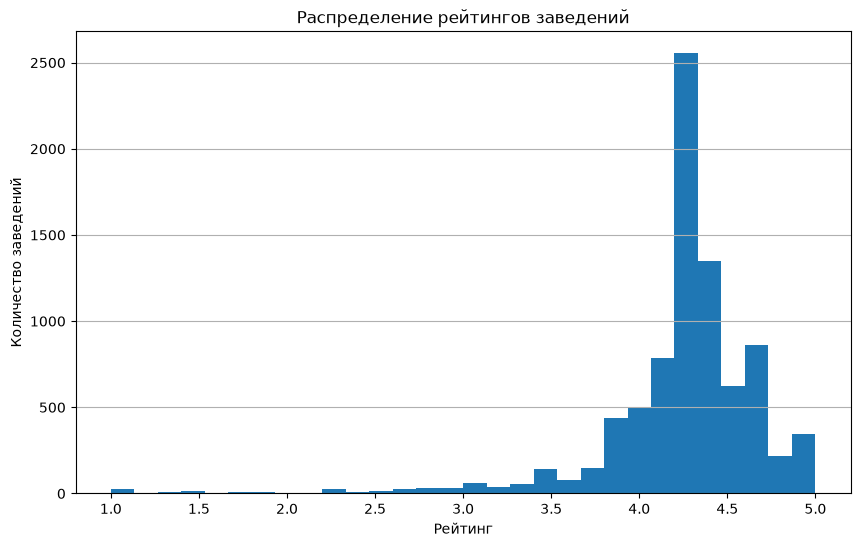

In [50]:
# Строим гистограмму рейтингов, смотрим их распределение
plt.figure(figsize=(10,6))

df['rating'].plot(
    kind='hist',
    bins=30
)

plt.title('Распределение рейтингов заведений')
plt.xlabel('Рейтинг')
plt.ylabel('Количество заведений')
plt.grid(axis='y')

plt.show()

In [51]:
# Считаем средний рейтинг по категориям
rating_by_category = (df.groupby('category')['rating'].mean().sort_values())
rating_by_category

category
быстрое питание    4.050249
кафе               4.124285
столовая           4.211429
булочная           4.268359
кофейня            4.277282
ресторан           4.290402
пиццерия           4.301264
бар,паб            4.387696
Name: rating, dtype: float64

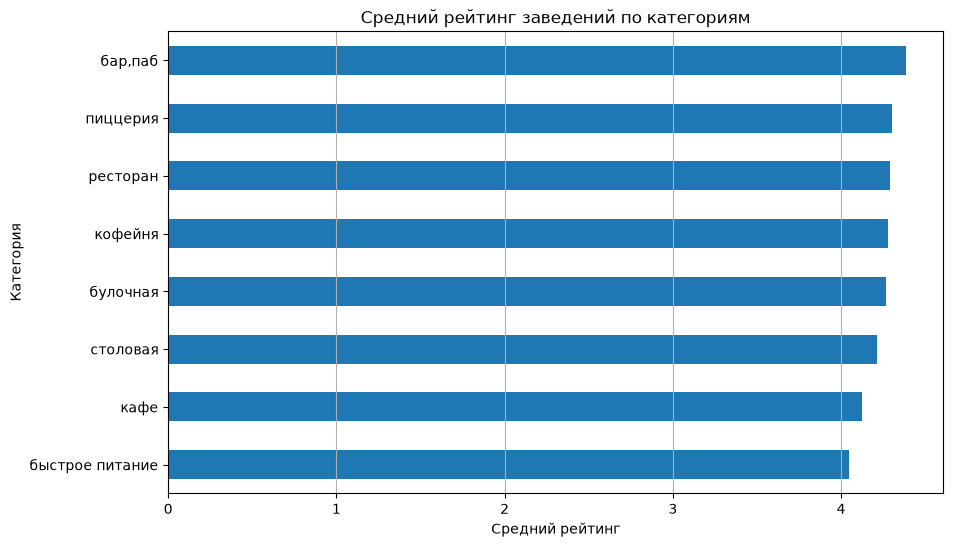

In [52]:
# Строим горизонтальную диаграмму
rating_by_category.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Средний рейтинг заведений по категориям')
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')
plt.grid(axis='x')

plt.show()

<Figure size 1200x600 with 0 Axes>

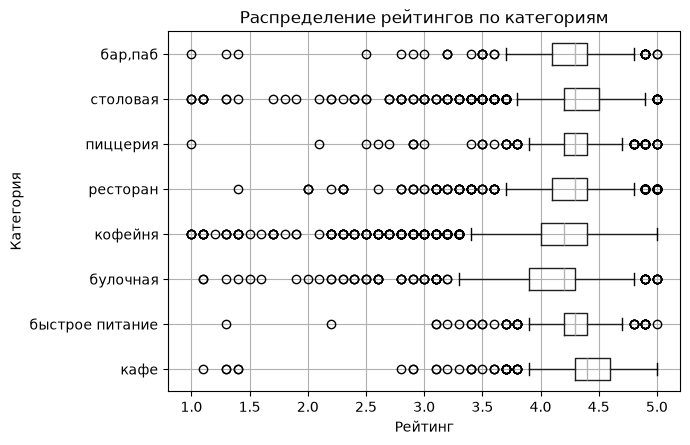

In [53]:
# Строим диаграмму размаха для анализа рейтинга заведений каждой категории
category_order = (df.groupby('category')['rating'].median().sort_values().index)

plt.figure(figsize=(12,6))

df.boxplot(
    column='rating',
    by='category',
    vert=False
)

plt.yticks(ticks=range(1, len(category_order)+1), labels=category_order)

plt.title('Распределение рейтингов по категориям')
plt.suptitle('')
plt.xlabel('Рейтинг')
plt.ylabel('Категория')

plt.show()

In [54]:
# Строим таблицу со статистикой рейтингов по каждой категории 
rating_stats = df.groupby('category')['rating'].agg(['mean', 'median', 'std', 'min', 'max', 'count']).round(2)
rating_stats = rating_stats.sort_values('mean', ascending=False)
rating_stats

,mean,median,std,min,max,count
category,,,,,,
"бар,паб",4.39,4.4,0.38,1.1,5.0,764
пиццерия,4.30,4.3,0.34,1.0,5.0,633
ресторан,4.29,4.3,0.41,1.0,5.0,2042
кофейня,4.28,4.3,0.37,1.4,5.0,1413
булочная,4.27,4.3,0.39,1.3,5.0,256
столовая,4.21,4.3,0.45,1.0,5.0,315
кафе,4.12,4.2,0.57,1.0,5.0,2376
быстрое питание,4.05,4.2,0.56,1.1,5.0,603


#### Промежуточный вывод по результатам исследования рейтингов заведений

В ходе анализа рейтингов заведений было установлено, что большинство значений сосредоточено в диапазоне от 4.0 до 4.5, что говорит о в целом высоком уровне качества заведений общественного питания.

Средние рейтинги по категориям различаются незначительно. Все категории находятся в узком диапазоне значений — примерно от 4.05 до 4.39, что свидетельствует об отсутствии сильной зависимости рейтинга от типа заведения.

Наиболее высокие средние рейтинги наблюдаются у:

- баров и пабов (4.39),
- пиццерий (4.30),
- ресторанов (4.29).

Наиболее низкие значения характерны для:

- заведений быстрого питания (4.05),
- кафе (4.12).

При этом медианные значения во всех категориях практически одинаковы (около 4.2–4.3), что подтверждает общую однородность распределения рейтингов.

Стандартное отклонение выше у кафе и заведений быстрого питания, что указывает на более широкий разброс оценок — от очень низких до высоких. Это может быть связано с различным уровнем качества таких заведений.

**Таким образом**, можно сделать вывод, что:

- различия в рейтингах между категориями незначительны;
- тип заведения оказывает слабое влияние на рейтинг;
- качество в большей степени зависит от конкретного заведения.

---

#### Анализируем корреляцию рейтинги заведений с другими данными (категория, положение, статус, количество мест и иными)

In [55]:
# Создаем копию датафрейма
df_corr = df.copy()
# Выбираем только нужные столбцы
df_corr = df_corr[[
    'rating',
    'category',
    'district',
    'chain',
    'seats',
    'price',
    'is_24_7',
    'middle_avg_bill'
]]

In [56]:
# Считаем матрицу корреляции phi_k
phik_matrix = df_corr.phik_matrix()
# Смотрим корреляцию с рейтингом
rating_phik = phik_matrix['rating'].sort_values(ascending=False)
# Выводим результат
rating_phik

interval columns not set, guessing: ['rating', 'chain', 'seats', 'middle_avg_bill']


rating             1.000000
price              0.281253
middle_avg_bill    0.211868
district           0.200761
category           0.189716
is_24_7            0.150365
chain              0.107833
seats              0.000000
Name: rating, dtype: float64

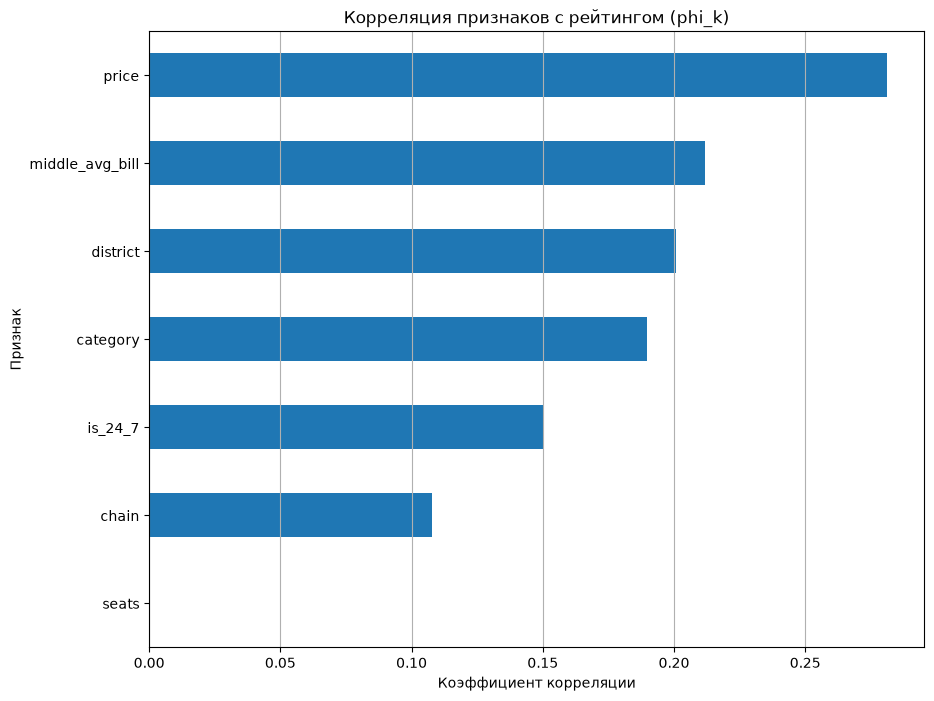

In [57]:
# Строим горизонтальную диаграмму
plt.figure(figsize=(10,8))
# Удаляем строку с самим рейтингом
rating_phik.drop('rating').sort_values().plot(
    kind='barh'
)
plt.title('Корреляция признаков с рейтингом (phi_k)')
plt.xlabel('Коэффициент корреляции')
plt.ylabel('Признак')
plt.grid(axis='x')
# Выводим результат
plt.show()

<Figure size 1000x600 with 0 Axes>

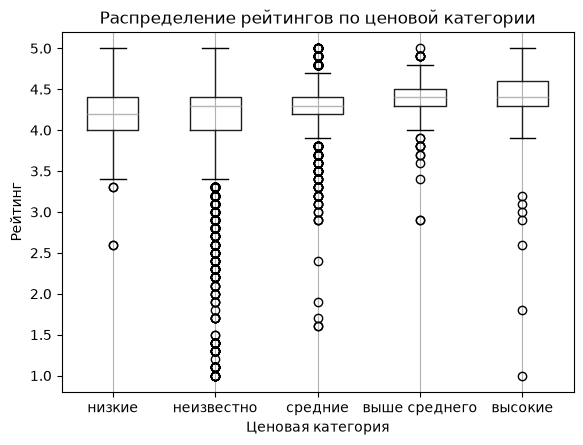

In [58]:
# Убираем пропуски
df_check = df.dropna(subset=['price', 'rating'])
# Сортируем категории по медиане рейтинга
price_order = (
    df_check
    .groupby('price')['rating']
    .median()
    .sort_values()
    .index
)
# Приводим price к категориальному типу с нужным порядком
df_check['price'] = pd.Categorical(
    df_check['price'],
    categories=price_order,
    ordered=True
)
# Строим boxplot
plt.figure(figsize=(10,6))

df_check.boxplot(
    column='rating',
    by='price'
)

plt.title('Распределение рейтингов по ценовой категории')
plt.suptitle('')
plt.xlabel('Ценовая категория')
plt.ylabel('Рейтинг')

plt.grid(axis='y')

plt.show()

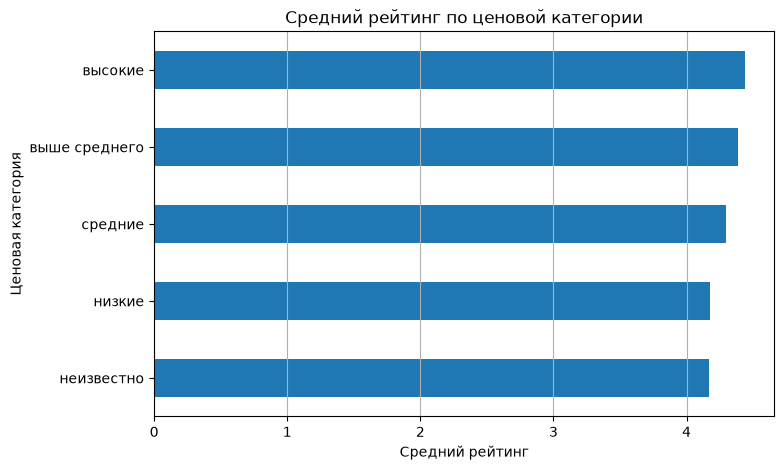

In [59]:
# Группируем и сортируем данные 
rating_by_price = (df_check.groupby('price')['rating'].mean().sort_values())
# Строим горизонтальную диаграмму
rating_by_price.plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Средний рейтинг по ценовой категории')
plt.xlabel('Средний рейтинг')
plt.ylabel('Ценовая категория')
plt.grid(axis='x')

plt.show()

#### Промежуточный вывод по результатам корреляционного анализа рейтинга заведений

В ходе корреляционного анализа исследовалась связь между рейтингом заведений и различными факторами: 
- категорией, 
- районом расположения, 
- статусом сетевого заведения, 
- количеством посадочных мест, 
- ценовой категорией, 
- круглосуточным режимом работы, 
- средним чеком. 

Для оценки зависимости рейтинга заведений от различных факторов был использован коэффициент phi_k, позволяющий анализировать как числовые, так и категориальные признаки без предварительного кодирования.

В результате анализа установлено, что наибольшую корреляцию с рейтингом показывает **ценовая категория заведения (price) (≈ 0.28)**;

Также наблюдается связь со следующими признаками:
- средний чек (middle_avg_bill) ≈ 0.21;
- административный район (district) ≈ 0.20;
- категория заведения (category) ≈ 0.19;

Остальные признаки (сетевой статус, количество мест, круглосуточный режим) оказывают ещё более слабое влияние.

Таким образом, все выявленные зависимости можно охарактеризовать как слабые, поскольку значения коэффициента phi_k не превышают 0.3.

Для проверки наиболее сильной зависимости был проведён дополнительный анализ распределения рейтингов по ценовым категориям. Он показал, что:

- более дорогие заведения в среднем имеют несколько более высокий рейтинг;
- при этом различия между категориями незначительны;
- внутри каждой ценовой категории наблюдается существенный разброс значений рейтинга.

На основании анализа распределения рейтинга по ценовой категории, отметим, что наблюдается слабая положительная связь между ценой и рейтингом: дорогие заведения в среднем имеют более высокие оценки и стабильное качество (узкий 'ящик', мало выбросов). Дешевый сегмент показывает стабильно средний уровень. Ключевая особенность — средний ценовой сегмент демонстрирует максимальный разброс рейтингов: здесь встречаются как заведения с оценками 1–3.5, так и с высокими 4.5–5.0. Это делает среднюю категорию самой нестабильной по качеству.

**Таким образом,** рейтинг заведения слабо зависит от рассмотренных факторов. Наиболее заметное влияние оказывает ценовая категория, однако она не является определяющим фактором. Вероятно, на рейтинг в большей степени влияют качественные характеристики (сервис, кухня, атмосфера), которые не представлены в данных.

---

#### Анализируем популярность сетевых заведений

In [60]:
# Оставляем только сетевые заведения
df_chain = df[df['chain'] == True]

In [61]:
# Сортируем заведения в порядке убывания и выводим топ-15 заведений
top_chains = (df_chain['name'].value_counts().head(15))
top_chains

name
Шоколадница                            120
Домино'с Пицца                          76
Додо Пицца                              74
One Price Coffee                        71
Яндекс Лавка                            69
Cofix                                   65
Prime                                   50
Хинкальная                              44
КОФЕПОРТ                                42
Кулинарная лавка братьев Караваевых     39
Теремок                                 38
Чайхана                                 37
Буханка                                 32
CofeFest                                32
Му-Му                                   27
Name: count, dtype: int64

In [62]:
# Считаем средний рейтинг заведений
# Оставляем только строки, где название входит в топ-15
top_chains_df = (
    df_chain[df_chain['name'].isin(top_chains.index)]
    .groupby('name') # Группируем строки по названию сети
    .agg({
        'rating': 'mean', # Считаем средний рейтинг
        'category': lambda x: x.mode()[0]  # Находим самое часто встречающееся значение в столбце 'category' 
    })
    .round(2) # Округляем средний рейтинг до 2-х знаков после запятой
)

In [63]:
# Добавляем количество заведений
top_chains_df['count'] = top_chains

In [64]:
# Сортируем и обобщаем в таблицу
top_chains_df = top_chains_df.sort_values(by='count', ascending=False)
top_chains_df

,rating,category,count
name,,,
Шоколадница,4.18,кофейня,120
Домино'с Пицца,4.17,пиццерия,76
Додо Пицца,4.29,пиццерия,74
One Price Coffee,4.06,кофейня,71
Яндекс Лавка,3.87,ресторан,69
Cofix,4.08,кофейня,65
Prime,4.12,ресторан,50
Хинкальная,4.32,кафе,44
КОФЕПОРТ,4.15,кофейня,42


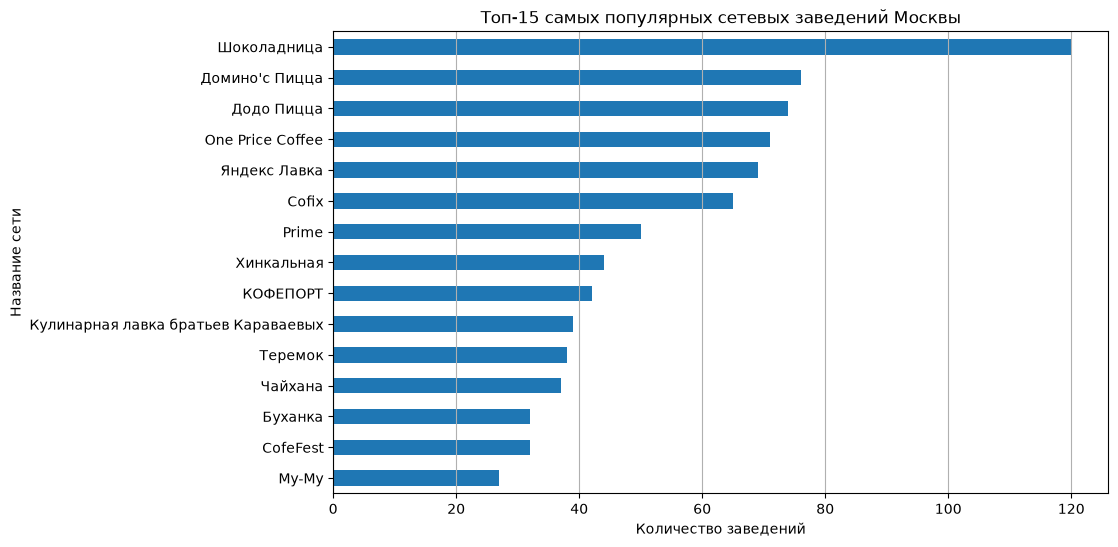

In [65]:
# Строим горизонтальную диаграмму популярности заведений
top_chains_df['count'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Топ-15 самых популярных сетевых заведений Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')
plt.grid(axis='x')

plt.show()

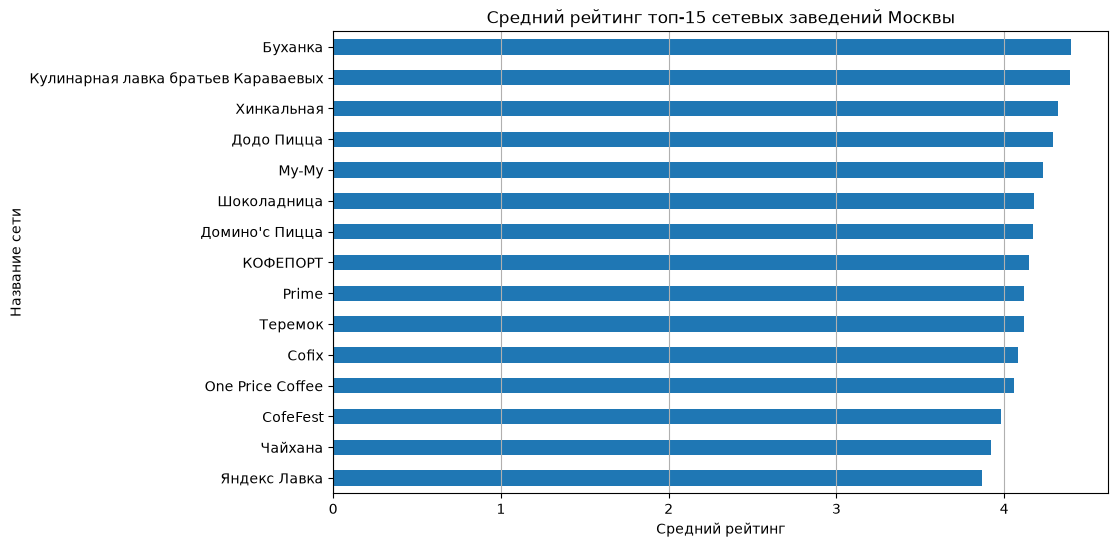

In [66]:
# Строим горизонтальную диаграмму в зависимости от рейтинга заведения
top_chains_df['rating'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Средний рейтинг топ-15 сетевых заведений Москвы')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.grid(axis='x')

plt.show()

#### Промежуточный вывод по результатам анализа популярности сетевых заведений Москвы

В ходе анализа были выделены только сетевые заведения, после чего определены топ-15 самых популярных сетей по количеству точек в Москве. Лидером по числу заведений стала «Шоколадница» со 120 точками, что значительно опережает остальных участников рейтинга. На втором месте располагается «Домино'с Пицца» с 76 заведениями, на третьем — «Додо Пицца» с 74 точками. Также в пятёрку лидеров вошли «One Price Coffee» (71 заведение) и «Яндекс Лавка» (69 заведений). 

Что касается среднего рейтинга, то здесь лидеры иные. Самый высокий средний рейтинг среди топ-15 сетей оказался у «Буханки» — 4,40 балла при всего 32 заведениях. Второй результат у «Кулинарной лавки братьев Караваевых» — 4,39 балла (39 заведений). Третье место занимает «Хинкальная» с рейтингом 4,32 балла (44 заведения). 

Отметим, что лидер по количеству заведений «Шоколадница» имеет рейтинг 4,18 балла, что находится на среднем уровне среди топ-15. Самый низкий рейтинг среди популярных сетей оказался у «Яндекс Лавки» — 3,87 балла при 69 заведениях.

По категориям распределение выглядит следующим образом: 
- кофейни представлены пятью сетями («Шоколадница», «One Price Coffee», «Cofix», «КОФЕПОРТ», «CofeFest»), 
- кафе — четырьмя сетями («Хинкальная», «Кулинарная лавка братьев Караваевых», «Чайхана», «Му-Му»), 
- рестораны — тремя сетями («Яндекс Лавка», «Prime», «Теремок»), 
- пиццерии — двумя сетями («Домино'с Пицца», «Додо Пицца»), 
- одна булочная («Буханка»).

На визуализациях видно, что количество заведений сети не всегда коррелирует с её рейтингом. Сети с небольшим количеством точек («Буханка», «Кулинарная лавка братьев Караваевых») показывают самые высокие оценки клиентов, в то время как некоторые крупные сети имеют рейтинг ниже среднего по выборке. Это может говорить о том, что при масштабировании сети поддерживать высокое качество обслуживания становится сложнее, либо о том, что небольшие сети более ориентированы на качество, а не на количество.

Таким образом, наиболее популярными по числу заведений категориями среди сетей являются кофейни и пиццерии, однако по качеству обслуживания (рейтингу) лидируют булочные и кафе с меньшим количеством точек.

---

#### Анализируем вариацию среднего чека заведения в зависимости от района Москвы


In [67]:
# Создаем копию данных для анализа цен
price_df = df[['district', 'middle_avg_bill']].copy()

In [68]:
# Убираем заведения, где нет данных о среднем чеке
price_df = price_df.dropna(subset=['middle_avg_bill'])

In [69]:
# Группируем заведения по районам и считаем средний чек
avg_bill_by_district = price_df.groupby('district')['middle_avg_bill'].mean().round(0).astype(int)
# Сортируем по убыванию
avg_bill_by_district = avg_bill_by_district.sort_values(ascending=False)
# Выводим результат
avg_bill_by_district

district
Центральный административный округ         1191
Западный административный округ            1053
Северный административный округ             928
Южный административный округ                834
Северо-Западный административный округ      822
Восточный административный округ            821
Юго-Западный административный округ         793
Северо-Восточный административный округ     717
Юго-Восточный административный округ        654
Name: middle_avg_bill, dtype: int64

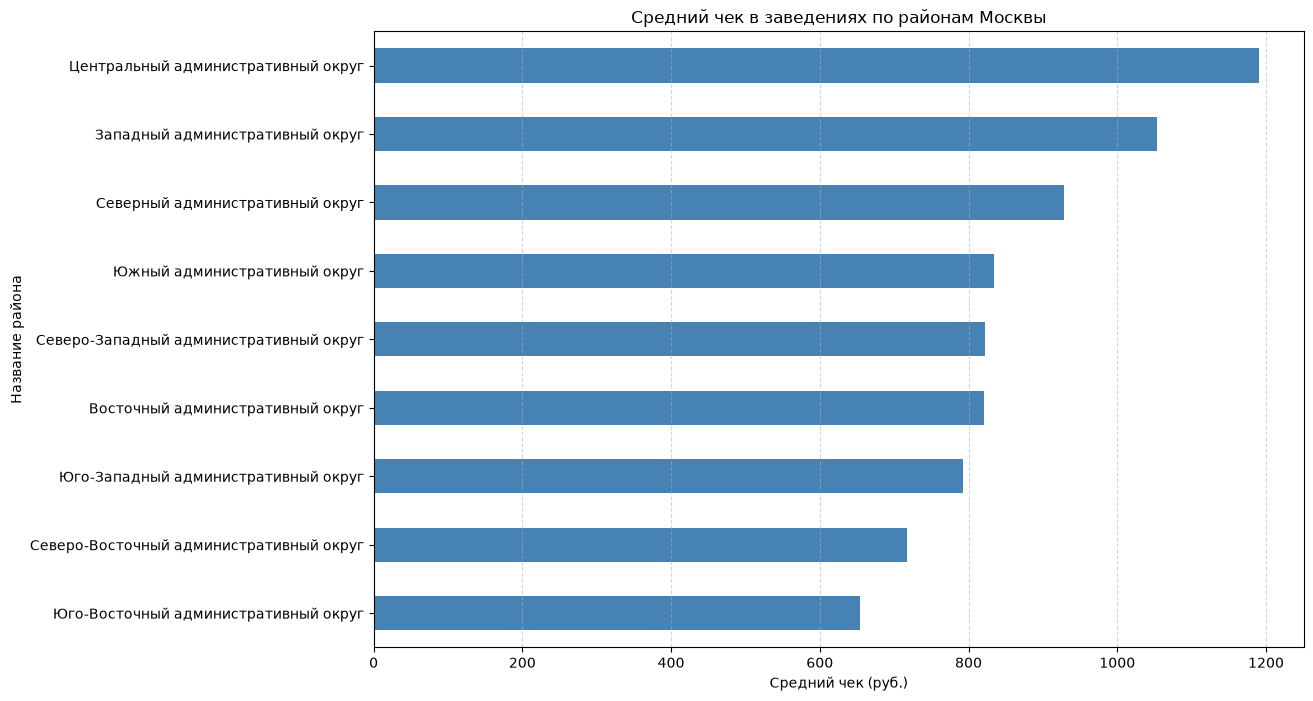

In [70]:
# Сортируем по убыванию и строим горизонтальную диаграмму
avg_bill_by_district.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(12, 8),
    color='steelblue'
)

plt.title('Средний чек в заведениях по районам Москвы')
plt.xlabel('Средний чек (руб.)')
plt.ylabel('Название района')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

In [71]:
# Выделяем Центральный округ отдельно
central_price = avg_bill_by_district['Центральный административный округ']
other_prices = avg_bill_by_district[avg_bill_by_district.index != 'Центральный административный округ']

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame({
    'Район': ['Центр (ЦАО)', 'Остальные районы'],
    'Средний чек (руб.)': [central_price, other_prices.mean()]
})

comparison_df

,Район,Средний чек (руб.)
0,Центр (ЦАО),1191.00
1,Остальные районы,827.75


In [72]:
# Порядок районов по удалённости от центра ('от центра к периферии')
distance_order = [
    'Центральный административный округ',
    'Северный административный округ',
    'Северо-Восточный административный округ',
    'Восточный административный округ',
    'Юго-Восточный административный округ',
    'Южный административный округ',
    'Юго-Западный административный округ',
    'Западный административный округ',
    'Северо-Западный административный округ'
]

# Берём средние чеки в нужном порядке
bill_by_distance = avg_bill_by_district[distance_order]

bill_by_distance

district
Центральный административный округ         1191
Северный административный округ             928
Северо-Восточный административный округ     717
Восточный административный округ            821
Юго-Восточный административный округ        654
Южный административный округ                834
Юго-Западный административный округ         793
Западный административный округ            1053
Северо-Западный административный округ      822
Name: middle_avg_bill, dtype: int64

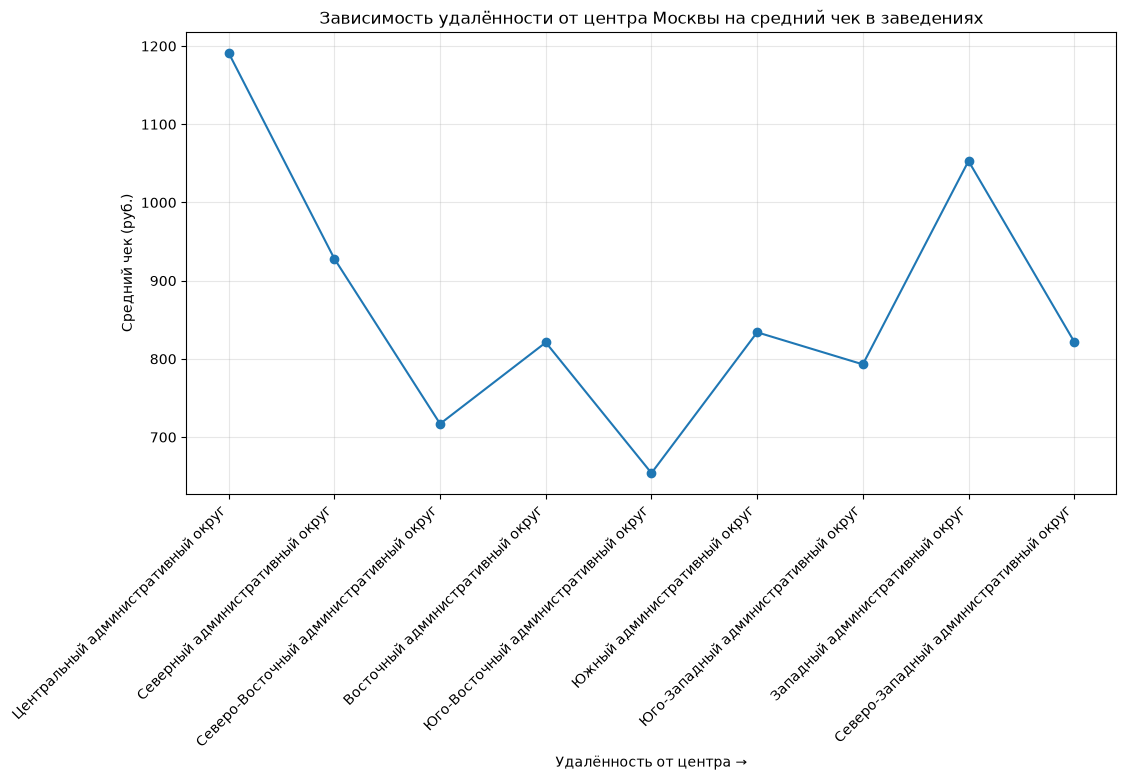

In [73]:
# Строим линейный график
bill_by_distance.plot(kind='line', marker='o', figsize=(12, 6))

plt.title('Зависимость удалённости от центра Москвы на средний чек в заведениях')
plt.xlabel('Удалённость от центра →')
plt.ylabel('Средний чек (руб.)')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)

plt.show()

#### Промежуточный вывод по результатам анализа среднего чека заведения в зависимости от района Москвы

Анализ среднего чека показал, что самый высокий уровень цен — в Центральном административном округе (1191 рубль). Западный округ также демонстрирует высокие показатели (1053 рубля). Самые низкие цены зафиксированы в Юго-Восточном (654 рубля) и Северо-Восточном (717 рублей) округах.

Однако говорить о строгой закономерности «чем дальше от центра, тем ниже цены» нельзя. Например, Западный округ, расположенный на периферии, имеет второй по величине средний чек, опережая многие более близкие к центру районы. Южный и Восточный округа также показывают средние чеки выше, чем у Северо-Восточного, который расположен ближе к центру.

Тем не менее, общая тенденция прослеживается: в центре цены самые высокие, а на периферии (особенно на востоке и юго-востоке) — самые низкие.

---
#### Промежуточный вывод по результатам исследовательского анализа данных

В ходе исследовательского анализа данных о заведениях общественного питания Москвы были изучены ключевые характеристики рынка общественного питания: 

- структура по категориям и районам, 
- соотношение сетевых и несетевых заведений, 
- вместимость, 
- рейтинги, 
- корреляционные связи, 
- популярные сетевые заведения,
- ценовая политика в разрезе районов.

Самыми важными результатами анализа стали следующие выводы:

**1. Структура рынка по категориям.** В данных представлено 8 категорий заведений. Наибольшее количество заведений приходится на кафе (2376 заведений) и рестораны (2042 заведения). Кофейни занимают третью позицию (1413 заведений). Наименьшее количество заведений у булочных (256) и столовых (315).

**2. Географическая концентрация.** В данных представлены 9 административных округов Москвы. Центральный административный округ лидирует по количеству заведений — 2242 объекта. В остальных округах количество заведений распределено следующим образом: Северный округ — 898, Южный — 892, Северо-Восточный — 890, Западный — 850, Восточный — 798, Юго-Восточный — 714, Юго-Западный — 709, Северо-Западный — 409. В Центральном округе среди всех категорий преобладают рестораны (670 заведений), кафе (464) и кофейни (428).

**3. Сетевое присутствие.** В выборке несетевых заведений — 5199, сетевых — 3203. В разрезе категорий наибольшее количество сетевых заведений наблюдается в следующих категориях: кофейни (720 сетевых при 693 несетевых), пиццерии (330 сетевых при 303 несетевых), булочные (157 сетевых при 99 несетевых). Наименьшее количество сетевых заведений в барах и пабах (168 сетевых при 596 несетевых) и столовых (88 сетевых при 227 несетевых).

**4. Вместимость заведений.** Медианное количество посадочных мест по всем заведениям составляет 75 мест. В разрезе категорий типичное (медианное) количество мест: булочные — 48,5 мест, пиццерии — 50 мест, кафе — 55 мест, быстрое питание — 60 мест, кофейни — 70 мест, столовые — 72 места, бары и пабы — 80 мест, рестораны — 80 мест. В данных присутствуют выбросы — заведения с количеством мест более 300 (максимальное значение — 1288 мест).

**5. Рейтинги.** Большинство заведений имеют рейтинг в диапазоне от 4,0 до 4,5 баллов. Средние рейтинги по категориям: бары и пабы — 4,39, пиццерии — 4,30, рестораны — 4,29, кофейни — 4,28, булочные — 4,27, столовые — 4,21, кафе — 4,12, быстрое питание — 4,05. Медианные значения во всех категориях составляют 4,2–4,4 балла.

**6. Корреляционный анализ.** В результате корреляционного анализа с использованием коэффициента phi_k (библиотека phik) выявлены следующие зависимости рейтинга заведений:

- Ценовая категория (price) — наиболее заметная связь (≈ 0.28)
- Средний чек (middle_avg_bill) — умеренная связь (≈ 0.21)
- Административный район (district) — слабая связь (≈ 0.20)
- Категория заведения (category) — слабая связь (≈ 0.19)

Все выявленные корреляции можно охарактеризовать как слабые или умеренные (максимальное значение не превышает 0.3). Это означает, что рассмотренные факторы влияют на рейтинг, но не являются определяющими. Вероятно, на оценку заведений в большей степени влияют качественные характеристики (сервис, кухня, атмосфера), которые не представлены в данных.

**7. Популярные сети.** Среди сетевых заведений лидером по количеству точек является «Шоколадница» (120 заведений). Далее следуют: «Домино'с Пицца» (76), «Додо Пицца» (74), «One Price Coffee» (71), «Яндекс Лавка» (69), «Cofix» (65). Самый высокий средний рейтинг среди топ-15 сетей у «Буханки» (4,40), «Кулинарной лавки братьев Караваевых» (4,39) и «Хинкальной» (4,32). По категориям топ-15 сетей распределяются следующим образом: 5 кофеен, 4 кафе, 3 ресторана, 2 пиццерии, 1 булочная.

**8. Ценовая география.** Средний чек по районам: Центральный округ — 1191 рубль, Западный — 1053 рубля, Северный — 928 рублей, Южный — 834 рубля, Северо-Западный — 822 рубля, Восточный — 821 рубль, Юго-Западный — 793 рубля, Северо-Восточный — 717 рублей, Юго-Восточный — 654 рубля. Средний чек в Центральном округе — 1191 рубль, средний чек в остальных районах — 828 рублей. Строгой зависимости «чем дальше от центра, тем ниже цены» не выявлено (Западный округ имеет второй по величине средний чек при значительной удалённости от центра), однако общая тенденция снижения цен на периферии прослеживается.

---
### Итоговые выводы

В рамках проекта был проведён исследовательский анализ рынка общественного питания Москвы на основе двух датасетов: информации о заведениях и их ценовой политике.

На этапе предобработки данные были очищены, объединены в единый датафрейм, обработаны пропуски, устранены дубликаты и созданы дополнительные признаки (например, признак круглосуточной работы).

Далее был проведён исследовательский анализ, включающий изучение категорий заведений, их распределения по районам, анализа сетевых и несетевых форматов, вместимости, рейтингов, цен и популярных сетей.

**Структура рынка**

Наиболее распространённые категории: кафе, рестораны и кофейни. Эти форматы формируют основу рынка общественного питания Москвы.

**География заведений**

Наибольшая концентрация заведений наблюдается в Центральном административном округе (ЦАО).
В ЦАО преобладают рестораны, кафе и кофейни — более дорогие и разнообразные форматы.

**Сетевые и несетевые**

Несетевых заведений больше (62%), чем сетевых (38%). Однако в некоторых категориях (кофейни, пиццерии, булочные) доля сетевых заведений выше 50%. Это говорит о высокой стандартизации и масштабируемости этих форматов.

**Посадочные места**

Основная масса заведений имеет от 40 до 140 мест. Были обнаружены выбросы (очень крупные заведения), вероятно: столовые, банкетные залы, фудкорты

Наиболее типичные значения:
- кафе: ~55 мест
- рестораны: ~80 мест
- кофейни: ~70 мест

**Рейтинги**

Средний рейтинг по всем категориям высокий (≈ 4.0–4.4). Различия между категориями незначительные.
Самые высокие рейтинги:
- бары/пабы
- пиццерии

Самые низкие:
- быстрое питание

**Корреляции**

В результате корреляционного анализа с использованием коэффициента phi_k выявлены следующие зависимости рейтинга заведений:

- Ценовая категория (price) — наиболее заметная связь (≈ 0.28)
- Средний чек (middle_avg_bill) — умеренная связь (≈ 0.21)
- Административный район (district) — слабая связь (≈ 0.20)
- Категория заведения (category) — слабая связь (≈ 0.19)

Все выявленные корреляции можно охарактеризовать как слабые или умеренные (максимальное значение не превышает 0.3). Это означает, что рассмотренные факторы влияют на рейтинг, но не являются определяющими.

**Популярные сети**

Рынок содержит ярко выраженные сети (особенно в кофейнях). 

**Цены**

В ЦАО средний чек выше. География влияет на ценовую политику.

---

### Рекомендации для инвестора

**Форматы, которые могут быть интересны для дальнейшего рассмотрения:**
- кофейни
- пиццерии
- небольшие кафе

Поскольку высокая доля сетей означает проверенную бизнес-модель и устойчивый спрос

**Локация**

ЦАО:
- высокая конкуренция
- высокая платежеспособность

Спальные районы:
- ниже конкуренция
- ниже средний чек

**Рекомендуется:**
- либо премиум-сегмент в центре
- либо массовый формат вне центра

**Размер заведения**

Наиболее распространённый формат заведений имеет около 50–80 посадочных мест. Такой размер соответствует основной части рынка и может рассматриваться как типичный формат для новых заведений.

**Ценовая стратегия**

- Анализ показал наличие слабой положительной связи между ценовой категорией и рейтингом заведений.
- Для нового проекта можно рассмотреть средний+ ценовой сегмент как потенциально интересное направление: он позволяет работать с более высокой стоимостью заказа, при этом сохраняет более широкий круг потенциальных клиентов по сравнению с премиальным сегментом.
- Дорогие заведения в исследуемой выборке характеризуются более высоким средним рейтингом и меньшим разбросом оценок, что может свидетельствовать о более стабильном качестве обслуживания.
- При выборе среднего ценового сегмента необходимо уделить особое внимание качеству продукта, концепции заведения и анализу конкурентов, так как именно этот сегмент характеризуется наибольшей неоднородностью рейтингов.

**Рекомендация:** при выходе на рынок целесообразно рассмотреть формат заведения среднего+ сегмента с акцентом на качество продукта и стабильный клиентский опыт.

**Формат сети**

Для модели с возможностью масштабирования стоит обратить внимание на категории с высокой долей сетевых заведений: кофейни, пиццерии и булочные.

Высокая представленность сетевых игроков в этих категориях может указывать на наличие стандартизированных бизнес-процессов и возможность тиражирования успешной модели.

**Рекомендация:** если целью является дальнейшее расширение бизнеса, стоит рассмотреть форматы с уже развитой сетевой моделью, адаптируя концепцию под особенности выбранной локации.